# Applied Nuclear Data Assimilation using GLLS

This example demonstrates the use of the **Generalized Least Squares (GLLS)** method to combine experimental benchmark data with prior nuclear data covariance information, producing a posterior set of cross section, nu-bar, and prompt fission spectrum adjustments. It then walks through the full verification path: exporting those adjustments directly onto existing ACE files with `AssimilationSuite.to_ace_direct`, and confirming that the resulting pointwise ACE perturbation matches the multigroup adjustment GLLS predicted.

Benchmarks:
- HMF001
- HMF002-001

Application:
- HMF002-002

### 1. Setup and Imports
We use `andalus` for the assimilation and ACE perturbation logic, `pandas` to interact with the adjustment data, and `matplotlib` for visualization.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import andalus

### 2. Reading Serpent Output
We use the `AssimilationSuite.from_yaml` method to load a set of benchmarks, an application, and nuclear data covariance information from a single configuration file.

The `config.yaml` file specifies which isotopes and reactions to include in the analysis. For this example, the configuration limits the assimilation to U-234, U-235, and U-238.

In [2]:
assimilation_suite = andalus.AssimilationSuite.from_yaml("config.yaml")

Reading ../data/hmf001.ser_res.m


  - done
Reading ../data/hmf001.ser_sens0.m
  - done
Reading ../data/hmf001.ser_det0.m
  - done
Reading ../data/hmf002-001.ser_res.m
  - done
Reading ../data/hmf002-001.ser_sens0.m
  - done
Reading ../data/hmf002-002.ser_res.m
  - done
Reading ../data/hmf002-002.ser_sens0.m
  - done


### 3. Performing the GLLS Adjustment
We now calculate the posterior suite. GLLS updates the nominal calculated values ($c$) and reduces their covariance based on the experimental evidence from the benchmarks, without ever touching the measured values ($m$) themselves.

$$
c_{post} = c_{prior} + G S^T (S G S^T + C_m)^{-1} (m - c_{prior})
$$

where $G$ is the nuclear data covariance, $S$ the sensitivity matrix, and $C_m$ the measurement covariance. The posterior calculated values for the benchmarks should move closer to the measurements, and the application (HMF002-002, which has no measurement of its own) should inherit a tightened uncertainty from the benchmarks it is correlated with.

Performing GLLS update on the assimilation suite...
    Number of benchmarks included in GLLS: 2
    Prior chi-squared with nuclear data: 0.0095
    Prior chi-squared without nuclear data: 1.3981
    Posterior chi-squared with nuclear data: 0.0002
    Posterior chi-squared without nuclear data: 0.0004



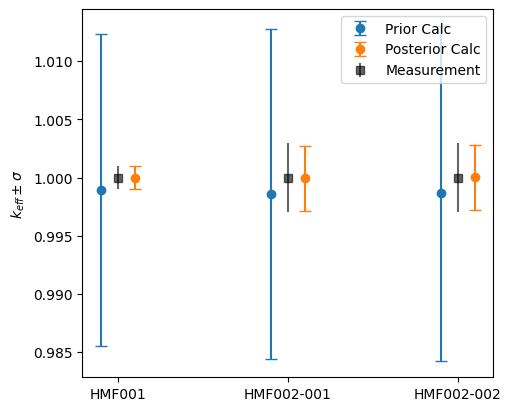

In [5]:
posterior_suite = assimilation_suite.glls()

prior_unc = assimilation_suite.propagate_nuclear_data_uncertainty()
post_unc = posterior_suite.propagate_nuclear_data_uncertainty()

fig, ax = plt.subplots(figsize=(5, 4), dpi=100, layout="constrained")

x = range(len(assimilation_suite.titles))
ax.errorbar([i - 0.1 for i in x], assimilation_suite.c, yerr=prior_unc, fmt="o", capsize=4, label="Prior Calc")
ax.errorbar([i + 0.1 for i in x], posterior_suite.c, yerr=post_unc, fmt="o", capsize=4, label="Posterior Calc")

ax.errorbar(
    x,
    assimilation_suite.m,
    yerr=assimilation_suite.dm,
    fmt="s",
    color="black",
    label="Measurement",
    alpha=0.6,
)

ax.set_xticks(x)
ax.set_xticklabels(assimilation_suite.titles)
ax.set_ylabel("$k_{eff} \\pm \\sigma$")
ax.legend()
plt.show()

### 4. Cross-Section Adjustments by Isotope
The posterior calculated values in the previous plot are produced by an underlying set of multigroup relative adjustments to each isotope's reactions, stored in `posterior_suite.xs_adjustment`. Plotting these directly shows which reactions GLLS moved, by how much, and in which energy range, for each of the three uranium isotopes in the configuration.

In [8]:
posterior_suite.xs_adjustment

ZAI     MT     E_min_eV      E_max_eV    
922350  2      1.000000e-05  1.000000e-01   -6.999980e-08
               1.000000e-01  5.400000e-01   -7.257689e-08
               5.400000e-01  4.000000e+00   -8.003348e-08
               4.000000e+00  8.315290e+00   -6.732921e-08
               8.315290e+00  1.370960e+01   -3.360391e-08
                                                 ...     
922380  35018  1.353350e+06  2.231300e+06   -6.864650e-05
               2.231300e+06  3.678790e+06    7.505350e-05
               3.678790e+06  6.065310e+06    4.516108e-04
               6.065310e+06  1.000000e+07    1.283729e-03
               1.000000e+07  1.964030e+07    3.430290e-03
Length: 396, dtype: float64

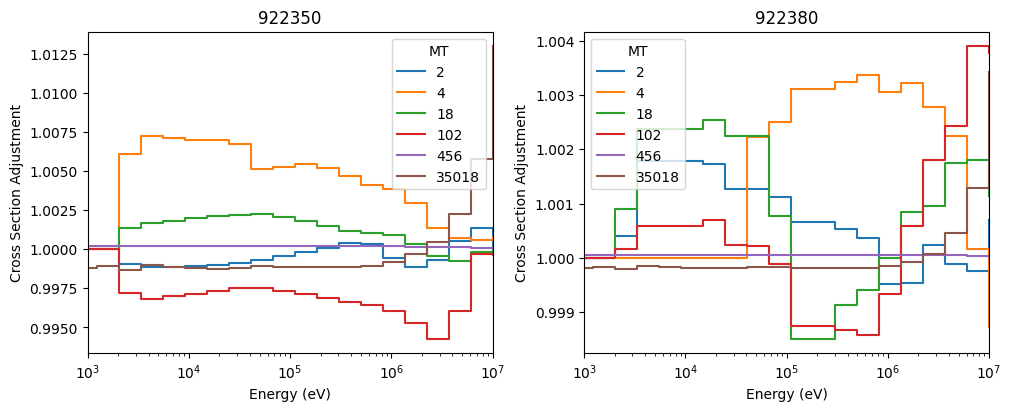

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

e_low = posterior_suite.xs_adjustment.loc[922350].loc[18].index.get_level_values("E_min_eV")

for i, zai in enumerate([922350, 922380]):
    ax = axs[i]

    for mt in posterior_suite.xs_adjustment.loc[922350].index.get_level_values("MT").unique():
        ax.step(e_low, posterior_suite.xs_adjustment.loc[zai].loc[[mt]].values + 1, where="post", label=mt)

    ax.set(
        xscale="log",
        xlabel="Energy (eV)",
        ylabel="Cross Section Adjustment",
        xlim=(1e3, 1e7),
        title=zai,
    )

    ax.legend(title="MT")

### 5. Exporting the Posterior to ACE
The multigroup adjustments above are a linear approximation of how the nuclear data should change to reproduce the benchmark measurements. To verify that approximation without reprocessing the ENDF evaluation through NJOY, `AssimilationSuite.to_ace_direct` applies the same adjustments directly onto an already-processed ACE file for each isotope, editing the pointwise cross sections, nu-bar, and prompt fission spectrum in place.

MTs are routed automatically: 452/456 (nu-bar) go to `ACE.perturb_nu`, MT $\geq$ 35000 (ANDALUS's MF $\times$ 1000 + MT chi convention, e.g. 35018 for the prompt fission spectrum of MT=18) go to `ACE.perturb_chi`, and every other reaction MT goes to `ACE.perturb`. Source ACE files are located through a Serpent-style xsdata file (`test.xsdata`); `create_xsdata=True` also writes one describing the perturbed output, so the posterior library can be used directly in a follow-up Serpent run.

U-234's ACE file only tabulates first through fourth-chance fission (MT=19/20/21/38) and the individual inelastic levels (MT=51..91), without separate MT=18/MT=4 aggregate arrays. `ACE.perturb` warns and redistributes the adjustment onto those constituents instead in that case, which is why the warnings below only mention ZAID=92234.

In [13]:
# Only test the methodology for U-235
posterior_suite.xs_adjustment = posterior_suite.xs_adjustment.loc[[922350]]

In [15]:
posterior_suite.to_ace_direct(out_dir="posterior_ace", xsdata_path="../data/test.xsdata", create_xsdata=True)

['posterior_ace\\92235.03c']

### 6. Verifying the Cross-Section Adjustment
We read back the prior source ACE file and the perturbed posterior ACE file for the same isotope, and compare the pointwise ratio between them to the multigroup adjustment GLLS originally predicted. If `to_ace_direct` applied the adjustment correctly, the pointwise ACE ratio should step through the same relative change as the GLLS curve at every energy.

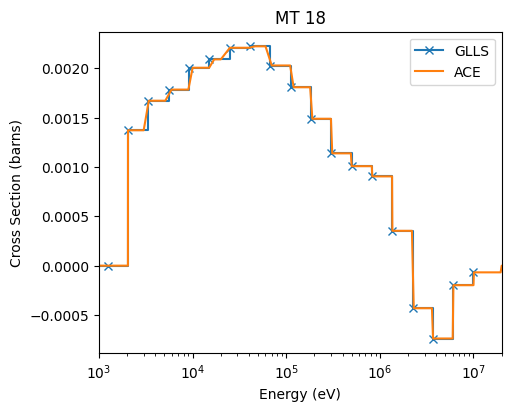

In [17]:
mt = 18
zai = 922350

fig, ax = plt.subplots(figsize=(5, 4), dpi=100, layout="constrained")

prior = andalus.ace.ACE.read(f"../data/{zai/10:.0f}.03c").reactions[mt]
post = andalus.ace.ACE.read(f"posterior_ace/{zai/10:.0f}.03c").reactions[mt]

ratio = post.xs / prior.xs

ax.step(
    posterior_suite.xs_adjustment.loc[zai].loc[mt].index.get_level_values("E_min_eV"),
    posterior_suite.xs_adjustment.loc[zai].loc[mt].values,
    marker='x', where="post", label="GLLS"
)
ax.plot(prior.energies*1e6, ratio-1, label="ACE")

ax.set(
    xscale="log",
    xlabel="Energy (eV)",
    ylabel="Cross Section (barns)",
    xlim=(1e3, 20e6),
    title=f"MT {mt}"
)

ax.legend()

The pointwise ACE ratio follows the GLLS step function closely across the full energy range. This confirms that `perturb` correctly redistributed the fission adjustment onto U-238's constituent reactions and that the perturbed ACE file reproduces the same multigroup shift used in the GLLS model, without relying on the linear approximation any further.

### 7. Verifying the Nu-Bar Adjustment
Nu-bar (the average number of neutrons released per fission) is perturbed independently of the cross sections via `ACE.perturb_nu`, using MT=456 for prompt nu-bar. We compare the same way: the pointwise ratio of the perturbed to the prior tabulated nu-bar values against the GLLS adjustment for MT=456.

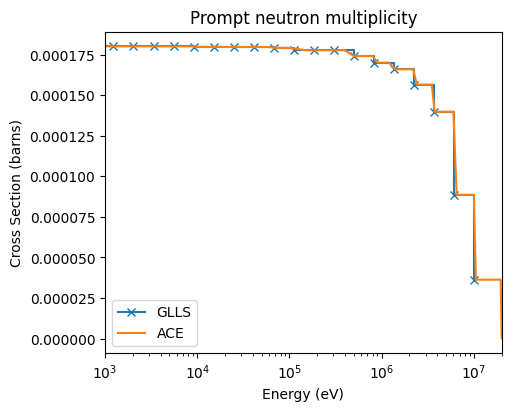

In [19]:
mt = 456

fig, ax = plt.subplots(figsize=(5, 4), dpi=100, layout="constrained")

# prior = u235_prior.nu["prompt"]
# post = u235_post.nu["prompt"]

prior = andalus.ace.ACE.read(f"../data/{zai/10:.0f}.03c").nu["prompt"]
post = andalus.ace.ACE.read(f"posterior_ace/{zai/10:.0f}.03c").nu["prompt"]

ratio = post.values / prior.values

ax.step(posterior_suite.xs_adjustment.loc[zai].loc[mt].index.get_level_values("E_min_eV"), posterior_suite.xs_adjustment.loc[zai].loc[mt].values, marker='x', where="post", label="GLLS")
ax.plot(prior.energy*1e6, ratio-1, label="ACE")

# ax.plot(prior.energies, prior.xs, label="Prior")
# ax.plot(post.energies, post.xs, label="Posterior")

ax.set(
    xscale="log",
    xlabel="Energy (eV)",
    ylabel="Cross Section (barns)",
    # yscale="log",
    xlim=(1e3, 20e6),
    title="Prompt neutron multiplicity"
)

ax.legend()

Again, the ACE nu-bar ratio matches the GLLS prediction at every incident energy, confirming that `perturb_nu` applied the adjustment to the correct tabulated nu-bar table.

### 8. Verifying the Prompt Fission Spectrum Adjustment
The prompt fission neutron spectrum $\chi(E_{out})$ is stored per incident energy in the ACE DLW block and perturbed via `ACE.perturb_chi` under MT=35018. ANDALUS does not yet resolve chi sensitivities by incident energy, so the same outgoing-energy-binned adjustment is applied identically to every incident-energy table; here we inspect one representative table (index 15) and compare its perturbed-to-prior PDF ratio against the GLLS adjustment.

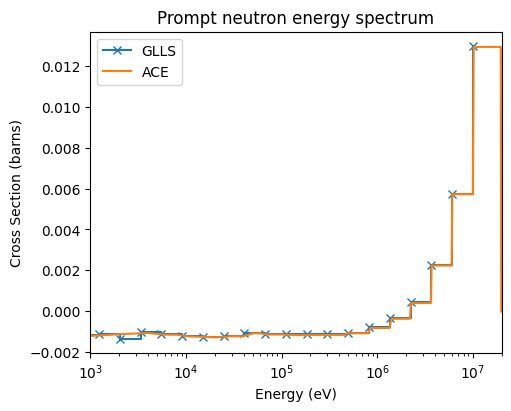

In [23]:
mt = 35018

fig, ax = plt.subplots(figsize=(5, 4), dpi=100, layout="constrained")

# prior = u235_prior.nu["prompt"]
# post = u235_post.nu["prompt"]

prior = andalus.ace.ACE.read(f"../data/{zai/10:.0f}.03c").chi[18].tables[15]
post = andalus.ace.ACE.read(f"posterior_ace/{zai/10:.0f}.03c").chi[18].tables[15]

ratio = post.pdf / prior.pdf

ax.step(posterior_suite.xs_adjustment.loc[zai].loc[mt].index.get_level_values("E_min_eV"), posterior_suite.xs_adjustment.loc[zai].loc[mt].values, marker='x', where="post", label="GLLS")
ax.plot(prior.energy_out*1e6, ratio-1, label="ACE")

# ax.plot(prior.energies, prior.xs, label="Prior")
# ax.plot(post.energies, post.xs, label="Posterior")

ax.set(
    xscale="log",
    xlabel="Energy (eV)",
    ylabel="Cross Section (barns)",
    # yscale="log",
    xlim=(1e3, 20e6),
    title="Prompt neutron energy spectrum"
)

ax.legend()

The pointwise chi ratio again follows the GLLS step function, confirming that `perturb_chi` applied the outgoing-energy adjustment to the prompt fission spectrum correctly. If however, the ACE data does not have an energy point within an energy group, no new energy point is added and the bin is skipped.

Together, the three verification plots show that `to_ace_direct` reproduces the GLLS posterior at the pointwise ACE level, so the perturbed library can be used directly in a Monte Carlo transport calculation to check the posterior without any further reliance on the linear GLLS approximation.